# Exploratory Data Analysis (EDA)

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

In [2]:
# Loading the datasets
df = pd.read_csv("../data/raw/train.csv")
test_df = pd.read_csv("../data/raw/test.csv")

In [3]:
df.shape, test_df.shape

((2000, 8), (500, 7))

In [4]:
df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [5]:
df.info(), test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      2000 non-null   int64
 1   prompt  2000 non-null   str  
 2   A       2000 non-null   str  
 3   B       2000 non-null   str  
 4   C       2000 non-null   str  
 5   D       2000 non-null   str  
 6   E       2000 non-null   str  
 7   answer  2000 non-null   str  
dtypes: int64(1), str(7)
memory usage: 1.9 MB
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      500 non-null    int64
 1   prompt  500 non-null    str  
 2   A       500 non-null    str  
 3   B       500 non-null    str  
 4   C       500 non-null    str  
 5   D       500 non-null    str  
 6   E       500 non-null    str  
dtypes: int64(1), str(6)
memory usage: 470.5 KB


(None, None)

## Cheking for Missing Values

In [6]:
df.isnull().sum(), test_df.isnull().sum()

(id        0
 prompt    0
 A         0
 B         0
 C         0
 D         0
 E         0
 answer    0
 dtype: int64,
 id        0
 prompt    0
 A         0
 B         0
 C         0
 D         0
 E         0
 dtype: int64)

## Checking Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["prompt"].duplicated().sum()

np.int64(242)

- The training dataset contains 242 duplicate questions, indicating that some concepts appear multiple times.
- This suggests the dataset may contain repeated knowledge patterns

In [ ]:
# Checking for duplicates with shuffled options
cols = ["prompt", "A", "B", "C", "D", "E", "answer"]
df.duplicated(subset=cols).sum()

np.int64(183)

- The training data contains 183 exact duplicates (with shuffled options)

In [10]:
# Removing Exact Duplicates
df_clean = df.drop_duplicates(
    subset=["prompt", "A", "B", "C", "D", "E", "answer"]
).reset_index(drop=True)
df_clean.shape

# Duplicate prompts after removing exact duplicates
df_clean["prompt"].duplicated().sum()

np.int64(59)

- Even after removing the exact duplicate rows, there are still 59 duplicate prompts in the dataset.

## Visualizing the distribution of answers

Text(0.5, 1.0, 'Distribution of Answers in the Training Set')

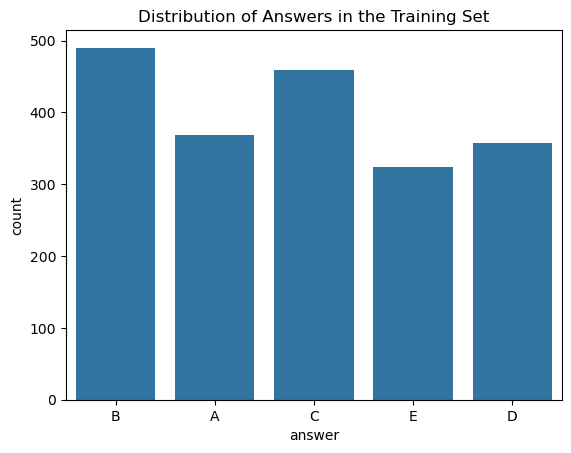

In [9]:
sns.countplot(x="answer", data=df)
plt.title("Distribution of Answers in the Training Set")

- The answer labels are not perfectly balanced. Option B appears most frequently while option E appears least frequent.
- However, all classes remain reasonably represented, there is no major class imbalance in the training set

## Lenght & Word Count Analysis

Maximum length of prompt: 337
Maximum length of option A: 472
Maximum length of option B: 662
Maximum length of option C: 530
Maximum length of option D: 450
Maximum length of option E: 587
Max of all: 662


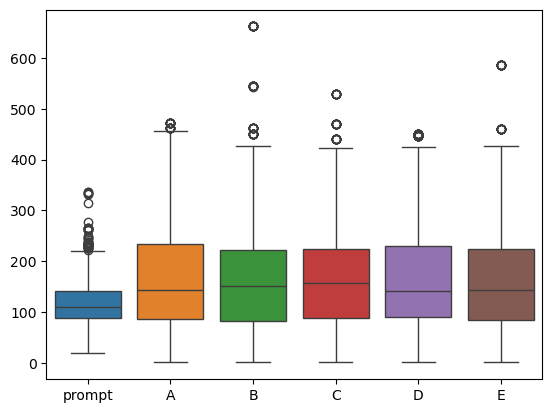

In [10]:
# Analyzing the length of prompts and options
lengths = df[["prompt", "A", "B", "C", "D", "E"]].apply(lambda x: x.str.len())
sns.boxplot(data=lengths)

print("Maximum length of prompt:", lengths["prompt"].max())
print("Maximum length of option A:", lengths["A"].max())
print("Maximum length of option B:", lengths["B"].max())
print("Maximum length of option C:", lengths["C"].max())
print("Maximum length of option D:", lengths["D"].max())
print("Maximum length of option E:", lengths["E"].max())
print("Max of all:", lengths.max().max())

Maximum word count of prompt: 51
Maximum word count of option A: 81
Maximum word count of option B: 118
Maximum word count of option C: 82
Maximum word count of option D: 78
Maximum word count of option E: 105
Max of all: 118


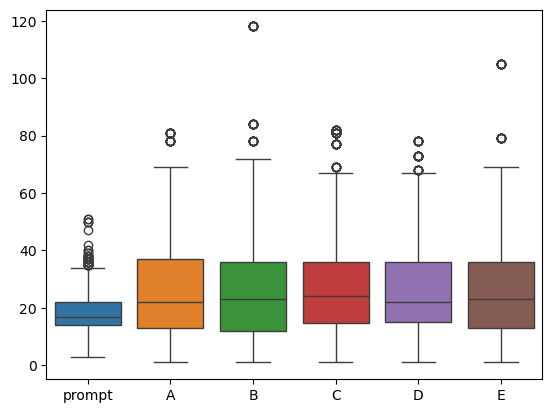

In [11]:
# Word Count
word_counts = df[["prompt", "A", "B", "C", "D", "E"]].apply(lambda x: x.str.split().str.len())
sns.boxplot(data=word_counts)

print("Maximum word count of prompt:", word_counts["prompt"].max())
print("Maximum word count of option A:", word_counts["A"].max())
print("Maximum word count of option B:", word_counts["B"].max())
print("Maximum word count of option C:", word_counts["C"].max())
print("Maximum word count of option D:", word_counts["D"].max())
print("Maximum word count of option E:", word_counts["E"].max())
print("Max of all:", word_counts.max().max())

## Word Cloud Visualization

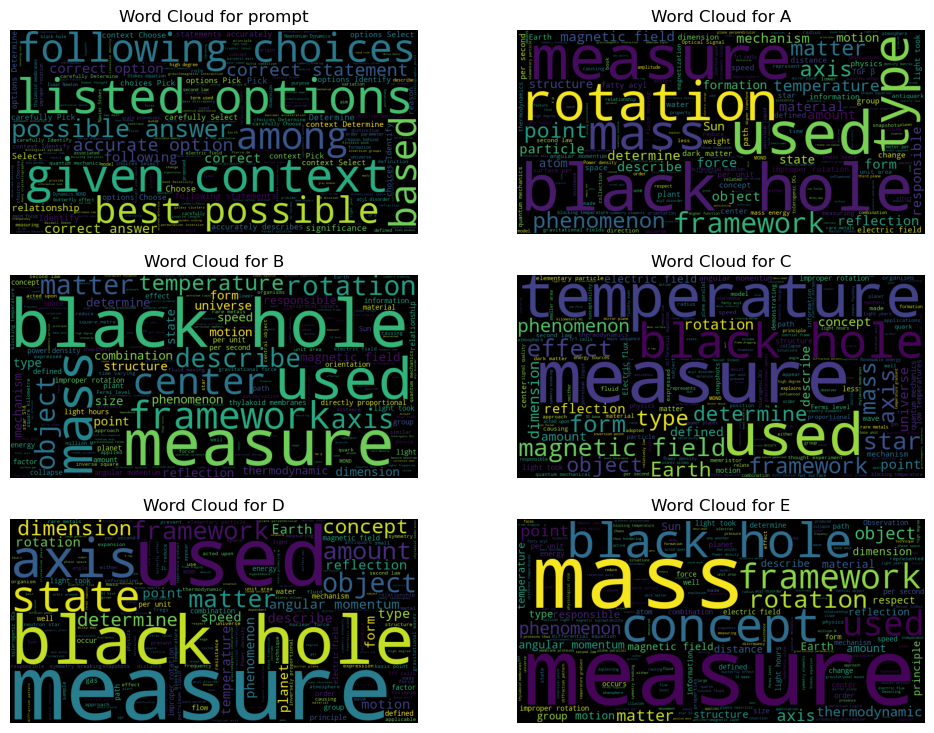

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
columns = ["prompt", "A", "B", "C", "D", "E"]
for i, col in enumerate(columns):
    axes[i // 2, i % 2].imshow(WordCloud(width=800, height=400).generate(" ".join(df[col])).to_image())
    axes[i // 2, i % 2].set_title(f"Word Cloud for {col}")
    axes[i // 2, i % 2].axis("off")

# TF-IDF Analysis

Text(0.5, 1.0, 'Top 50 TF-IDF Features in Prompts')

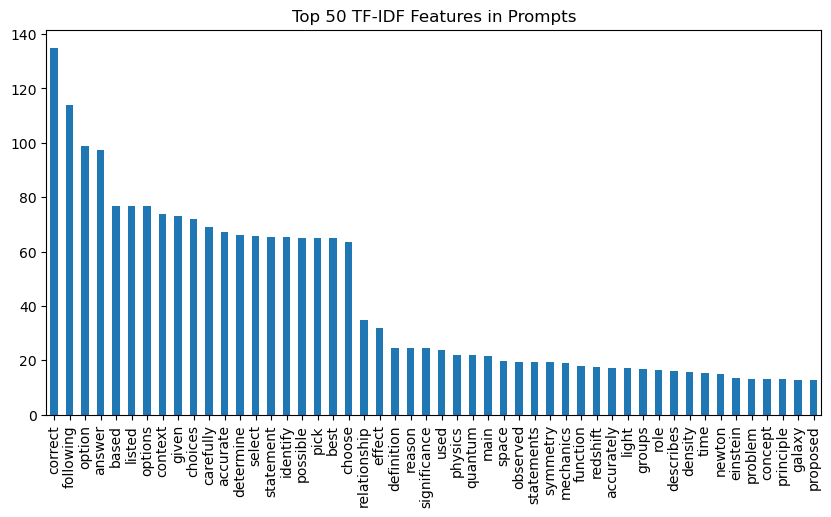

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf_idf = TfidfVectorizer(stop_words="english", max_features=1000)

tf_idf_matrix = tf_idf.fit_transform(df["prompt"]).todense()

tf_idf_df = pd.DataFrame(tf_idf_matrix, columns=tf_idf.get_feature_names_out())

tf_idf_df.sum().sort_values(ascending=False).head(50).plot(kind="bar", figsize=(10, 5))
plt.title("Top 50 TF-IDF Features in Prompts")

- instructional words such as correct, following, option, answer occur most frequently across prompts.

## PCA of TF-IDF Features

Text(0.5, 1.0, 'PCA of TF-IDF Features')

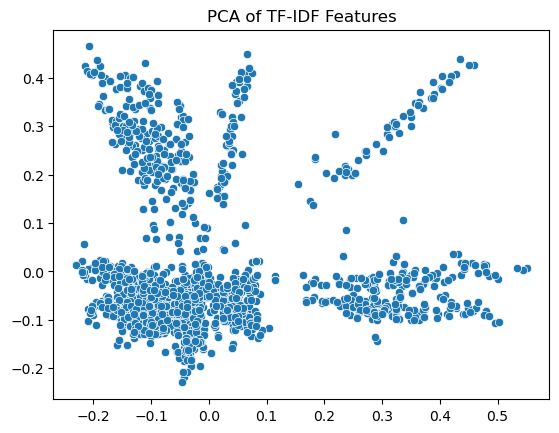

In [62]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
tf_idf_pca = pca.fit_transform(pd.DataFrame(tf_idf_matrix))

sns.scatterplot(x=tf_idf_pca[:, 0], y=tf_idf_pca[:, 1])
plt.title("PCA of TF-IDF Features")

- Several clusters are visible, indicating that certain groups of questions are similar or have similar topics.
- There are multiple topics or themes present in the dataset, as evidenced by the distinct clusters in the PCA plot.

## Correct vs Incorrect Option Length

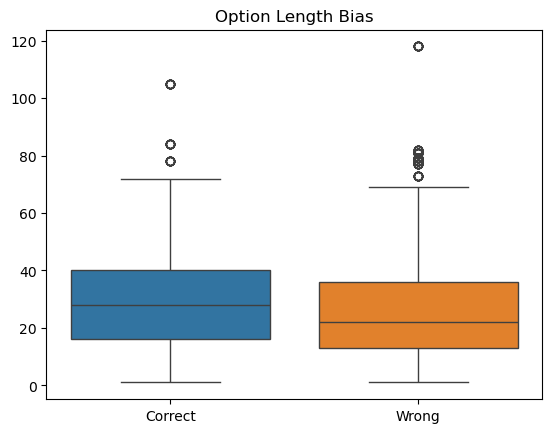

Correct Avg Length: 28.659
Wrong Avg Length: 25.68475


In [65]:
options = ["A","B","C","D","E"]

correct_lengths = []
wrong_lengths = []

for _, row in df.iterrows():
    correct = row["answer"]
    for opt in options:
        length = len(str(row[opt]).split())
        if opt == correct:
            correct_lengths.append(length)
        else:
            wrong_lengths.append(length)

sns.boxplot(data=[correct_lengths,wrong_lengths])
plt.xticks([0,1],["Correct","Wrong"])
plt.title("Option Length Bias")
plt.show()

print("Correct Avg Length:", np.mean(correct_lengths))
print("Wrong Avg Length:",np.mean(wrong_lengths))


- Correct options are slightly longer on average than incorrect options.

## Nagation Analysis

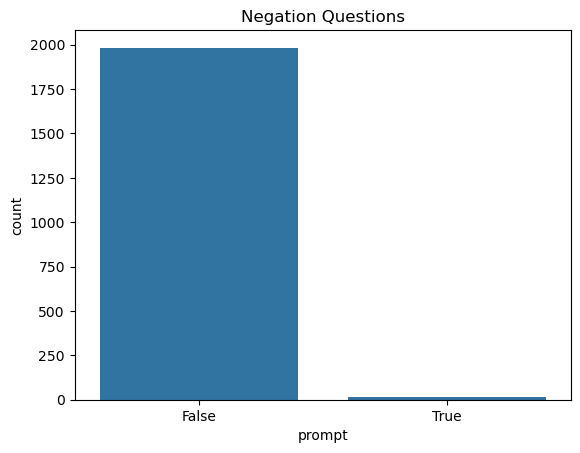

prompt
False    1983
True       17
Name: count, dtype: int64

In [70]:
def has_negation(text):
    negation_words = [
    "not",
    "except",
    "false",
    "incorrect",
    "least",
    "never"
    ]
    text = str(text).lower()
    return any(
        word in text
        for word in negation_words
    )

has_negation_in_prompt = df["prompt"].apply(has_negation)

sns.countplot(x=has_negation_in_prompt)
plt.title("Negation Questions")
plt.show()

has_negation_in_prompt.value_counts()

- This shows in most of the questions we need to find the correct answers not the incorrect ones. Like - Select the correct answer. Not -Which is Not Correct answer.

## Correct Answer Positions

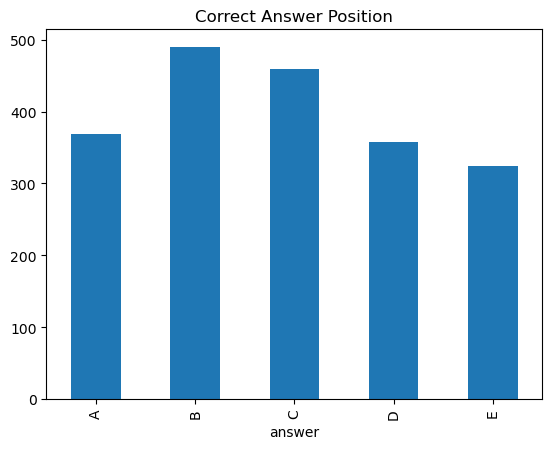

answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64


In [66]:
answer_dist = (df["answer"].value_counts().sort_index())
answer_dist.plot(kind="bar")
plt.title("Correct Answer Position")
plt.show()

print(answer_dist)

- Option B is the most common correct answer, followed by option C. 
- Option E is the least common correct answer.

## Longest Option Bias

In [71]:
longest_correct = 0

for _, row in df.iterrows():
    lengths = {
        opt: len(str(row[opt]).split())
        for opt in ["A","B","C","D","E"]
    }
    longest = max(lengths.items(), key=lambda x: x[1])[0]
    if longest == row["answer"]:
        longest_correct += 1

ratio = longest_correct / len(df)

print(f"Longest option correct: {ratio:.3f}")

Longest option correct: 0.349


- The longest option is the correct answer in approximately 35% of the questions. But random chance among five options is only 20%